# SFUMATO vs Points2Regions / P2R

This notebook compares SFUMATO clusters with Points2Regions clusters.

It supports two input modes:
1. use `cluster_p2r` already present in `adata.obs`;
2. load an external P2R table with coordinates or IDs.

It produces two heatmaps:
1. all SFUMATO assignments, without probability filtering;
2. high-confidence SFUMATO assignments, using `p1 >= P1_THRESHOLD`.


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex, to_rgb

try:
    from scipy.cluster import hierarchy
except Exception:
    hierarchy = None

sns.set_theme(style="white", context="paper")
pd.set_option("display.max_columns", 80)


c:\Users\alegi784\AppData\Local\anaconda3\envs\gene_analysis\Lib\site-packages\scanpy\_utils\__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
c:\Users\alegi784\AppData\Local\anaconda3\envs\gene_analysis\Lib\site-packages\scanpy\__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
c:\Users\alegi784\AppData\Local\anaconda3\envs\gene_analysis\Lib\site-packages\scanpy\readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
# -------------------------
# Parameters
# -------------------------
SFUMATO_H5AD = r"full\newcolors\mousexeniumcell_BGM68to45_BIN7_F5_SVD10_FULL.h5ad"

# Leave empty to use P2R columns already present in adata.obs.
P2R_TABLE = ""

OUTPUT_DIR = "sfumato_points2regions_comparison"
P1_THRESHOLD = 0.8
NORMALIZATION = "row"  # "row", "column", or "none"

# Matching options for external P2R table
MATCH_METHOD = "coordinate"  # "coordinate" or "id"
COORDINATE_METHOD = "astype_int"  # "astype_int", "round", or "floor"
SFUMATO_COORD_SCALE = 1.0
P2R_COORD_SCALE = 1.0

# SFUMATO columns in adata.obs
SFUMATO_X_COL = "x"
SFUMATO_Y_COL = "y"
SFUMATO_ID_COL = ""  # used only if MATCH_METHOD == "id" for external P2R
SFUMATO_CLUSTER_COL = "cluster"
SFUMATO_COLOR_COL = "color_hard_hsv"
SFUMATO_P1_COL = "p1"
SFUMATO_COMPL_P1_COL = "compl_p1"

# P2R columns
P2R_CLUSTER_COL = "cluster_p2r"
P2R_COLOR_COL = "color_p2r"
P2R_X_COL = "x"
P2R_Y_COL = "y"
P2R_ID_COL = ""  # used only if MATCH_METHOD == "id" for external P2R


In [3]:
def read_table(path, **kwargs):
    path = Path(path)
    suffix = path.suffix.lower()
    if suffix == ".parquet":
        return pd.read_parquet(path, **kwargs)
    if suffix in {".csv", ".txt"}:
        return pd.read_csv(path, **kwargs)
    if suffix in {".tsv", ".tab"}:
        return pd.read_csv(path, sep="\t", **kwargs)
    raise ValueError(f"Unsupported table format: {path}")


def decode_if_bytes(series):
    return series.map(lambda x: x.decode("utf-8") if isinstance(x, (bytes, bytearray)) else x)


def add_confidence(obs, p1_col="p1", compl_p1_col="compl_p1"):
    obs = obs.copy()
    if p1_col in obs.columns:
        obs["p1"] = pd.to_numeric(obs[p1_col], errors="coerce")
    elif compl_p1_col in obs.columns:
        obs["p1"] = 1 - pd.to_numeric(obs[compl_p1_col], errors="coerce")
    else:
        warnings.warn(
            f"Neither {p1_col!r} nor {compl_p1_col!r} found. "
            "The high-confidence subset will be unavailable."
        )
        obs["p1"] = np.nan
    return obs


def add_integer_coordinates(df, x_col, y_col, x_out="x_int", y_out="y_int", scale=1.0, method="astype_int"):
    df = df.copy()
    x = pd.to_numeric(df[x_col], errors="coerce") / scale
    y = pd.to_numeric(df[y_col], errors="coerce") / scale
    if method == "round":
        df[x_out] = np.rint(x).astype("Int64")
        df[y_out] = np.rint(y).astype("Int64")
    elif method == "floor":
        df[x_out] = np.floor(x).astype("Int64")
        df[y_out] = np.floor(y).astype("Int64")
    elif method == "astype_int":
        df[x_out] = np.trunc(x).astype("Int64")
        df[y_out] = np.trunc(y).astype("Int64")
    else:
        raise ValueError("method must be one of: 'astype_int', 'round', 'floor'")
    return df


def clean_cluster_labels(series, drop_values=("-1", "nan", "None")):
    labels = series.astype("string")
    labels = labels.where(~labels.isna(), other=pd.NA)
    labels = labels.str.replace(r"\.0$", "", regex=True)
    return labels.where(~labels.isin(drop_values), other=pd.NA)


def load_json_mapping(path):
    if path is None or str(path).strip() == "":
        return None
    with open(path, "r") as f:
        data = json.load(f)
    return {str(k): float(v) for k, v in data.items()}


def grayscale_map(values, low=0.92, high=0.20):
    values = pd.Series(values, dtype="float64")
    finite = values.replace([np.inf, -np.inf], np.nan).dropna()
    if finite.empty:
        scaled = pd.Series(0.5, index=values.index)
    elif finite.max() == finite.min():
        scaled = pd.Series(0.5, index=values.index)
    else:
        scaled = (values - finite.min()) / (finite.max() - finite.min())
    scaled = scaled.fillna(0.0).clip(0, 1)
    gray = low + (high - low) * scaled
    return gray.map(lambda g: to_hex((g, g, g)))


def safe_color_map(df, label_col, color_col):
    if color_col is None or color_col not in df.columns:
        return {}
    tmp = df[[label_col, color_col]].dropna().copy()
    tmp[label_col] = clean_cluster_labels(tmp[label_col])
    tmp = tmp.dropna(subset=[label_col])
    return tmp.drop_duplicates(label_col).set_index(label_col)[color_col].astype(str).to_dict()


def build_matrix(df, row_col, col_col, normalization="row"):
    clean = df[[row_col, col_col]].dropna().copy()
    clean[row_col] = clean_cluster_labels(clean[row_col])
    clean[col_col] = clean_cluster_labels(clean[col_col])
    clean = clean.dropna(subset=[row_col, col_col])
    counts = clean.pivot_table(index=row_col, columns=col_col, aggfunc="size", fill_value=0)
    if counts.empty:
        raise ValueError("No overlapping assignments after filtering. Check input paths, columns, or coordinate matching.")
    counts = counts.sort_index(axis=0).sort_index(axis=1)
    if normalization == "row":
        denom = counts.sum(axis=1).replace(0, np.nan)
        matrix = counts.div(denom, axis=0).fillna(0)
    elif normalization == "column":
        denom = counts.sum(axis=0).replace(0, np.nan)
        matrix = counts.div(denom, axis=1).fillna(0)
    elif normalization in {"none", None}:
        matrix = counts
    else:
        raise ValueError("normalization must be 'row', 'column', or 'none'")
    return counts, matrix


def order_matrix(matrix, cluster_rows=True, order_columns_by_dominant_row=True):
    ordered = matrix.copy()
    if cluster_rows and ordered.shape[0] > 1 and hierarchy is not None:
        linkage_matrix = hierarchy.linkage(ordered.values, method="average", metric="euclidean")
        ordered = ordered.iloc[hierarchy.leaves_list(linkage_matrix)]
    if order_columns_by_dominant_row and ordered.shape[1] > 1:
        values = ordered.to_numpy()
        dominant = np.argmax(values, axis=0)
        weak = values.max(axis=0) <= 0
        dominant = np.where(weak, 10_000, dominant)
        ordered = ordered.iloc[:, np.argsort(dominant)]
    return ordered


def plot_heatmap(
    matrix,
    title,
    row_color_map=None,
    row_numeric_annotation=None,
    row_numeric_label="SFUMATO transcript fraction",
    col_color_map=None,
    col_numeric_annotation=None,
    col_numeric_label="Reference size",
    row_label="SFUMATO cluster",
    col_label="Reference cluster",
    cmap="inferno",
    output_path=None,
):
    matrix = order_matrix(matrix)
    row_colors = None
    row_ann = {}
    if row_color_map:
        row_ann["SFUMATO color"] = [row_color_map.get(str(idx), "#bdbdbd") for idx in matrix.index]
    if row_numeric_annotation is not None:
        row_values = pd.Series({str(k): v for k, v in row_numeric_annotation.items()})
        row_ann[row_numeric_label] = grayscale_map([row_values.get(str(idx), np.nan) for idx in matrix.index]).tolist()
    if row_ann:
        row_colors = pd.DataFrame(row_ann, index=matrix.index)

    col_colors = None
    col_ann = {}
    if col_color_map:
        col_ann["Reference color"] = [col_color_map.get(str(idx), "#bdbdbd") for idx in matrix.columns]
    if col_numeric_annotation is not None:
        col_values = pd.Series({str(k): v for k, v in col_numeric_annotation.items()})
        col_ann[col_numeric_label] = grayscale_map([col_values.get(str(idx), np.nan) for idx in matrix.columns]).tolist()
    if col_ann:
        col_colors = pd.DataFrame(col_ann, index=matrix.columns)

    fig_height = max(6, matrix.shape[0] * 0.35 + 2)
    fig_width = max(7, matrix.shape[1] * 0.35 + 2)
    g = sns.clustermap(
        matrix,
        row_cluster=False,
        col_cluster=False,
        cmap=cmap,
        row_colors=row_colors,
        col_colors=col_colors,
        cbar_pos=(0.02, 0.80, 0.03, 0.12),
        figsize=(fig_width, fig_height),
        yticklabels=True,
        xticklabels=True,
    )
    plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0, fontsize=8)
    plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, fontsize=8)
    g.ax_heatmap.set_xlabel(col_label, fontsize=11)
    g.ax_heatmap.set_ylabel(row_label, fontsize=11)
    g.fig.suptitle(title, fontsize=13, y=1.02)
    if output_path:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        g.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {output_path}")
    plt.show()
    return g


In [4]:
adata = sc.read_h5ad(SFUMATO_H5AD)
obs = add_confidence(adata.obs, p1_col=SFUMATO_P1_COL, compl_p1_col=SFUMATO_COMPL_P1_COL)

print("SFUMATO obs columns:", obs.columns.tolist())
if P2R_TABLE:
    p2r = read_table(P2R_TABLE)
    print("P2R columns:", p2r.columns.tolist())
    display(p2r.head(3))
else:
    p2r = None
    print("Using P2R columns from adata.obs.")


SFUMATO obs columns: ['x', 'y', 'target_name', 'bin_id', 'cluster', 'color_hard_hsv', 'color_log_hsv', 'compl_p1', 'cluster_p2r', 'color_p2r', 'p1']
Using P2R columns from adata.obs.


In [5]:
base_cols = [SFUMATO_CLUSTER_COL, "p1"]
if SFUMATO_COLOR_COL in obs.columns:
    base_cols.append(SFUMATO_COLOR_COL)

if not P2R_TABLE:
    p2r_cols = [P2R_CLUSTER_COL]
    if P2R_COLOR_COL in obs.columns:
        p2r_cols.append(P2R_COLOR_COL)
    required = base_cols + p2r_cols
    missing = [c for c in required if c not in obs.columns]
    if missing:
        raise KeyError(f"Missing columns in adata.obs: {missing}")

    merged = obs[required].copy()
    merged = merged.rename(
        columns={
            SFUMATO_CLUSTER_COL: "sfumato_cluster",
            SFUMATO_COLOR_COL: "sfumato_color",
            P2R_CLUSTER_COL: "p2r_cluster",
            P2R_COLOR_COL: "p2r_color",
        }
    )
else:
    sfumato_cols = base_cols.copy()
    if MATCH_METHOD == "coordinate":
        sfumato_cols += [SFUMATO_X_COL, SFUMATO_Y_COL]
    elif MATCH_METHOD == "id":
        if not SFUMATO_ID_COL or not P2R_ID_COL:
            raise ValueError("Set SFUMATO_ID_COL and P2R_ID_COL when MATCH_METHOD == 'id'.")
        sfumato_cols.append(SFUMATO_ID_COL)
    else:
        raise ValueError("MATCH_METHOD must be 'coordinate' or 'id'.")

    missing_sfumato = [c for c in sfumato_cols if c not in obs.columns]
    if missing_sfumato:
        raise KeyError(f"Missing SFUMATO columns in adata.obs: {missing_sfumato}")

    sfumato = obs[sfumato_cols].copy()
    sfumato = sfumato.rename(
        columns={
            SFUMATO_CLUSTER_COL: "sfumato_cluster",
            SFUMATO_COLOR_COL: "sfumato_color",
            SFUMATO_X_COL: "sfumato_x",
            SFUMATO_Y_COL: "sfumato_y",
            SFUMATO_ID_COL: "match_id",
        }
    )

    p2r_cols = [P2R_CLUSTER_COL]
    if P2R_COLOR_COL in p2r.columns:
        p2r_cols.append(P2R_COLOR_COL)
    if MATCH_METHOD == "coordinate":
        p2r_cols += [P2R_X_COL, P2R_Y_COL]
    else:
        p2r_cols.append(P2R_ID_COL)

    missing_p2r = [c for c in p2r_cols if c not in p2r.columns]
    if missing_p2r:
        raise KeyError(f"Missing P2R columns: {missing_p2r}")

    p2r2 = p2r[p2r_cols].copy()
    p2r2 = p2r2.rename(
        columns={
            P2R_CLUSTER_COL: "p2r_cluster",
            P2R_COLOR_COL: "p2r_color",
            P2R_X_COL: "p2r_x",
            P2R_Y_COL: "p2r_y",
            P2R_ID_COL: "match_id",
        }
    )

    if MATCH_METHOD == "coordinate":
        sfumato = add_integer_coordinates(
            sfumato, "sfumato_x", "sfumato_y",
            scale=SFUMATO_COORD_SCALE, method=COORDINATE_METHOD
        )
        p2r2 = add_integer_coordinates(
            p2r2, "p2r_x", "p2r_y",
            scale=P2R_COORD_SCALE, method=COORDINATE_METHOD
        )
        p2r2 = p2r2.drop_duplicates(subset=["x_int", "y_int", "p2r_cluster"])
        merged = sfumato.merge(p2r2, on=["x_int", "y_int"], how="inner")
    else:
        merged = sfumato.merge(p2r2, on="match_id", how="inner")

merged["sfumato_cluster"] = clean_cluster_labels(merged["sfumato_cluster"])
merged["p2r_cluster"] = clean_cluster_labels(merged["p2r_cluster"])

print(f"Matched rows: {len(merged):,}")
display(merged.head())


Matched rows: 42,196,646


,sfumato_cluster,p1,sfumato_color,p2r_cluster,p2r_color
0,15,0.978788,#6fe100,25,#96b559
1,15,0.998898,#6fe100,25,#96b559
2,15,0.998241,#6fe100,25,#96b559
3,32,0.507923,#ff6804,12,#00c1ff
4,36,0.999790,#ff00e6,2,#f150ff


In [6]:
sfumato_color_map = safe_color_map(merged, "sfumato_cluster", "sfumato_color")
p2r_color_map = safe_color_map(merged, "p2r_cluster", "p2r_color") if "p2r_color" in merged.columns else {}

def run_p2r_comparison(df, label):
    counts, matrix = build_matrix(df, "sfumato_cluster", "p2r_cluster", normalization=NORMALIZATION)
    print(f"{label}: matrix shape = {matrix.shape}; total overlap count = {counts.to_numpy().sum():,}")
    display(counts.head())
    output_path = Path(OUTPUT_DIR) / f"sfumato_vs_points2regions_{label}.pdf"
    return plot_heatmap(
        matrix,
        title=f"SFUMATO vs Points2Regions ({label}; {NORMALIZATION}-normalized)",
        row_color_map=sfumato_color_map,
        col_color_map=p2r_color_map,
        row_label="SFUMATO cluster",
        col_label="P2R cluster",
        output_path=output_path,
    )


all: matrix shape = (45, 45); total overlap count = 41,984,165


p2r_cluster,0,1,10,11,12,13,14,15,16,17,18,19,2,20,21,22,23,24,25,26,27,28,29,3,30,31,32,33,34,35,36,37,38,39,4,40,41,42,43,44,5,6,7,8,9
sfumato_cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0,0,376,2421,29027,3801,90,381,4786,1412,123,41,0,85,49,8,11485,30065,40,771,113,12,104,21,445,414,1605,3139,57,13989,83808,16386,17636,783,70,4,124,732,123,76,2,0,2755,1274,113
1,0,0,0,0,0,0,1,474,11,0,0,0,0,0,0,0,2833,2478,0,29,4,3,10,0,465,150,615,244,0,1265,120497,125474,6475,1,0,0,7,591,287,4,0,0,54,0,49
10,0,0,11,2,1116,1,122,2280,693,76,11,45,0,105,10,1,426262,178470,1226,77401,38873,20545,4857,0,10625,440,714,1784,124,20390,223,326,76,107,0,27,286,11880,25965,63,0,0,978,0,2048
11,0,0,2,0,0,0,57,12913,0,0,0,0,0,206,0,47,91402,1002,1188,55331,2301209,629183,98791,0,403381,954,3014,12715,1596,198,0,0,0,0,0,0,24,1243,2681,0,0,1,0,0,23926
12,0,0,0,0,0,0,0,1613,0,0,2,0,0,78,21,157,112,37,10421,685622,534171,33756,211643,0,353,2,9875,85635,9799,62,0,0,3,0,0,0,0,498,388,0,0,0,0,0,691


Saved: sfumato_points2regions_comparison\sfumato_vs_points2regions_all.pdf


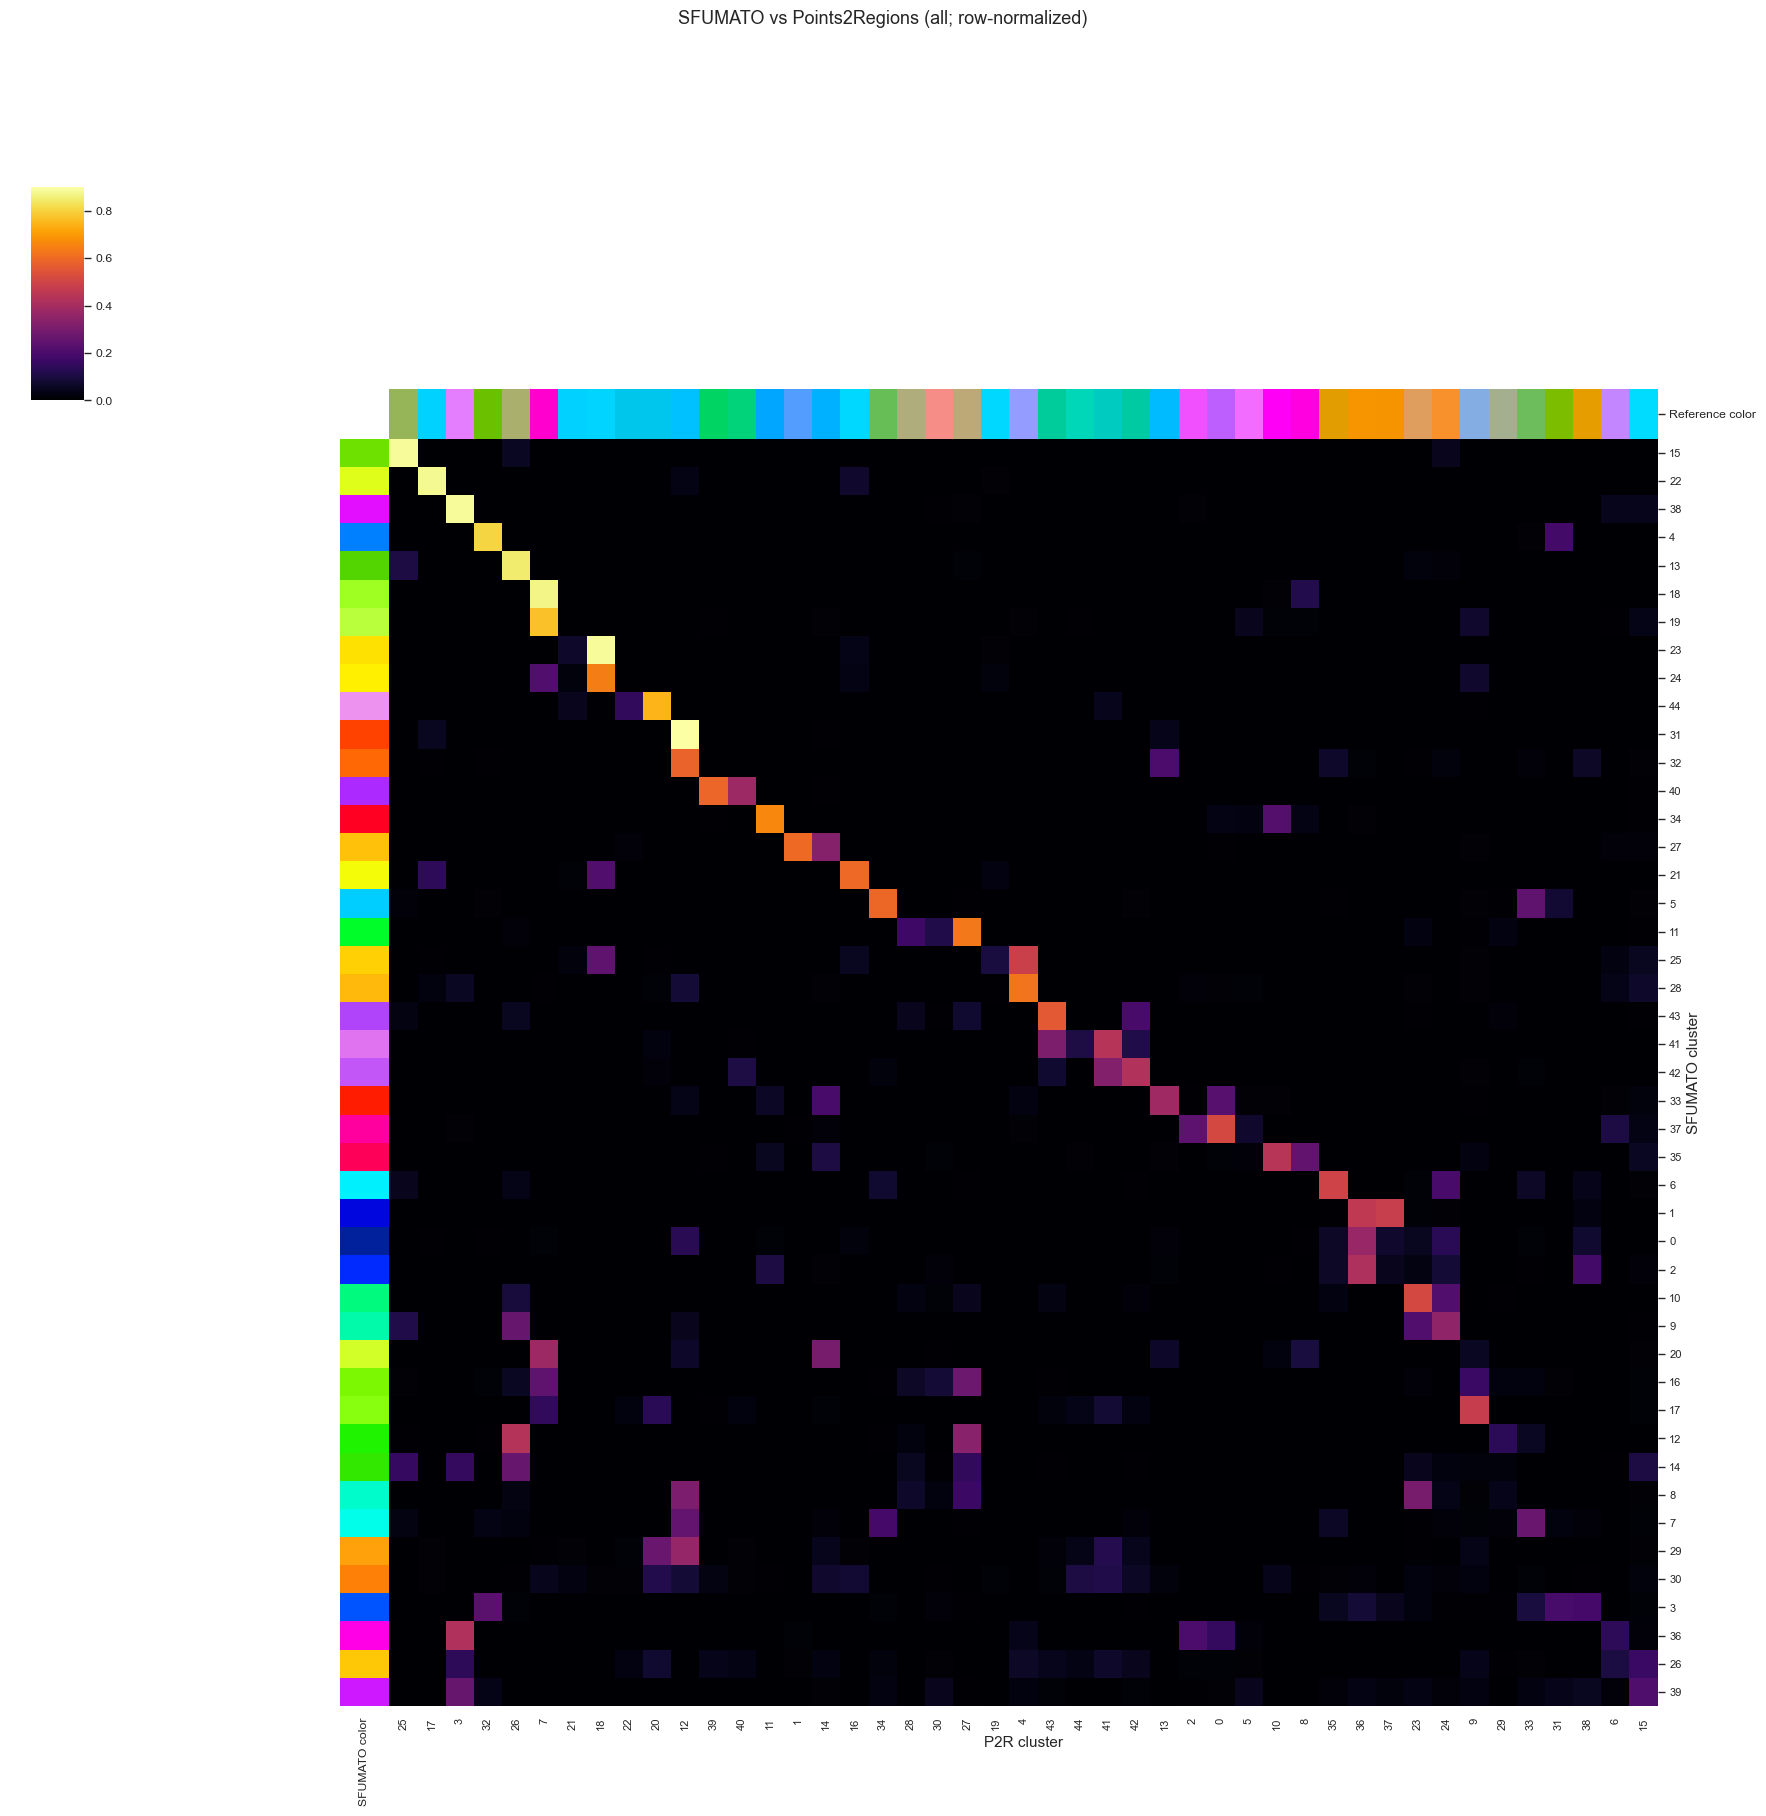

In [7]:
g_all = run_p2r_comparison(merged, label="all")


High-confidence threshold: p1 >= 0.8
High-confidence matched rows: 33,666,798 / 42,196,646
p1_ge_0_8: matrix shape = (45, 45); total overlap count = 33,666,798


p2r_cluster,0,1,10,11,12,13,14,15,16,17,18,19,2,20,21,22,23,24,25,26,27,28,29,3,30,31,32,33,34,35,36,37,38,39,4,40,41,42,43,44,5,6,7,8,9
sfumato_cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0,0,202,1465,14241,1304,19,103,2890,711,60,20,0,29,27,7,4322,17765,12,365,55,9,35,13,143,113,455,1211,24,7749,59460,10478,9675,422,38,2,56,258,44,39,0,0,1453,791,22
1,0,0,0,0,0,0,0,187,0,0,0,0,0,0,0,0,1092,935,0,5,0,0,2,0,182,24,144,61,0,434,90856,106624,3009,0,0,0,0,149,47,0,0,0,0,0,2
10,0,0,1,0,86,0,16,797,264,11,3,17,0,11,3,0,294357,120087,414,42383,17435,10340,1743,0,3960,34,110,330,27,8388,26,35,3,25,0,1,90,4866,13145,26,0,0,118,0,594
11,0,0,0,0,0,0,3,6507,0,0,0,0,0,80,0,1,50145,165,192,19408,1988424,547589,58106,0,383788,62,1213,4777,517,33,0,0,0,0,0,0,17,227,780,0,0,0,0,0,12394
12,0,0,0,0,0,0,0,593,0,0,0,0,0,16,6,30,25,5,3311,520721,365019,14417,161472,0,122,1,5489,61411,4486,27,0,0,0,0,0,0,0,79,87,0,0,0,0,0,165


Saved: sfumato_points2regions_comparison\sfumato_vs_points2regions_p1_ge_0_8.pdf


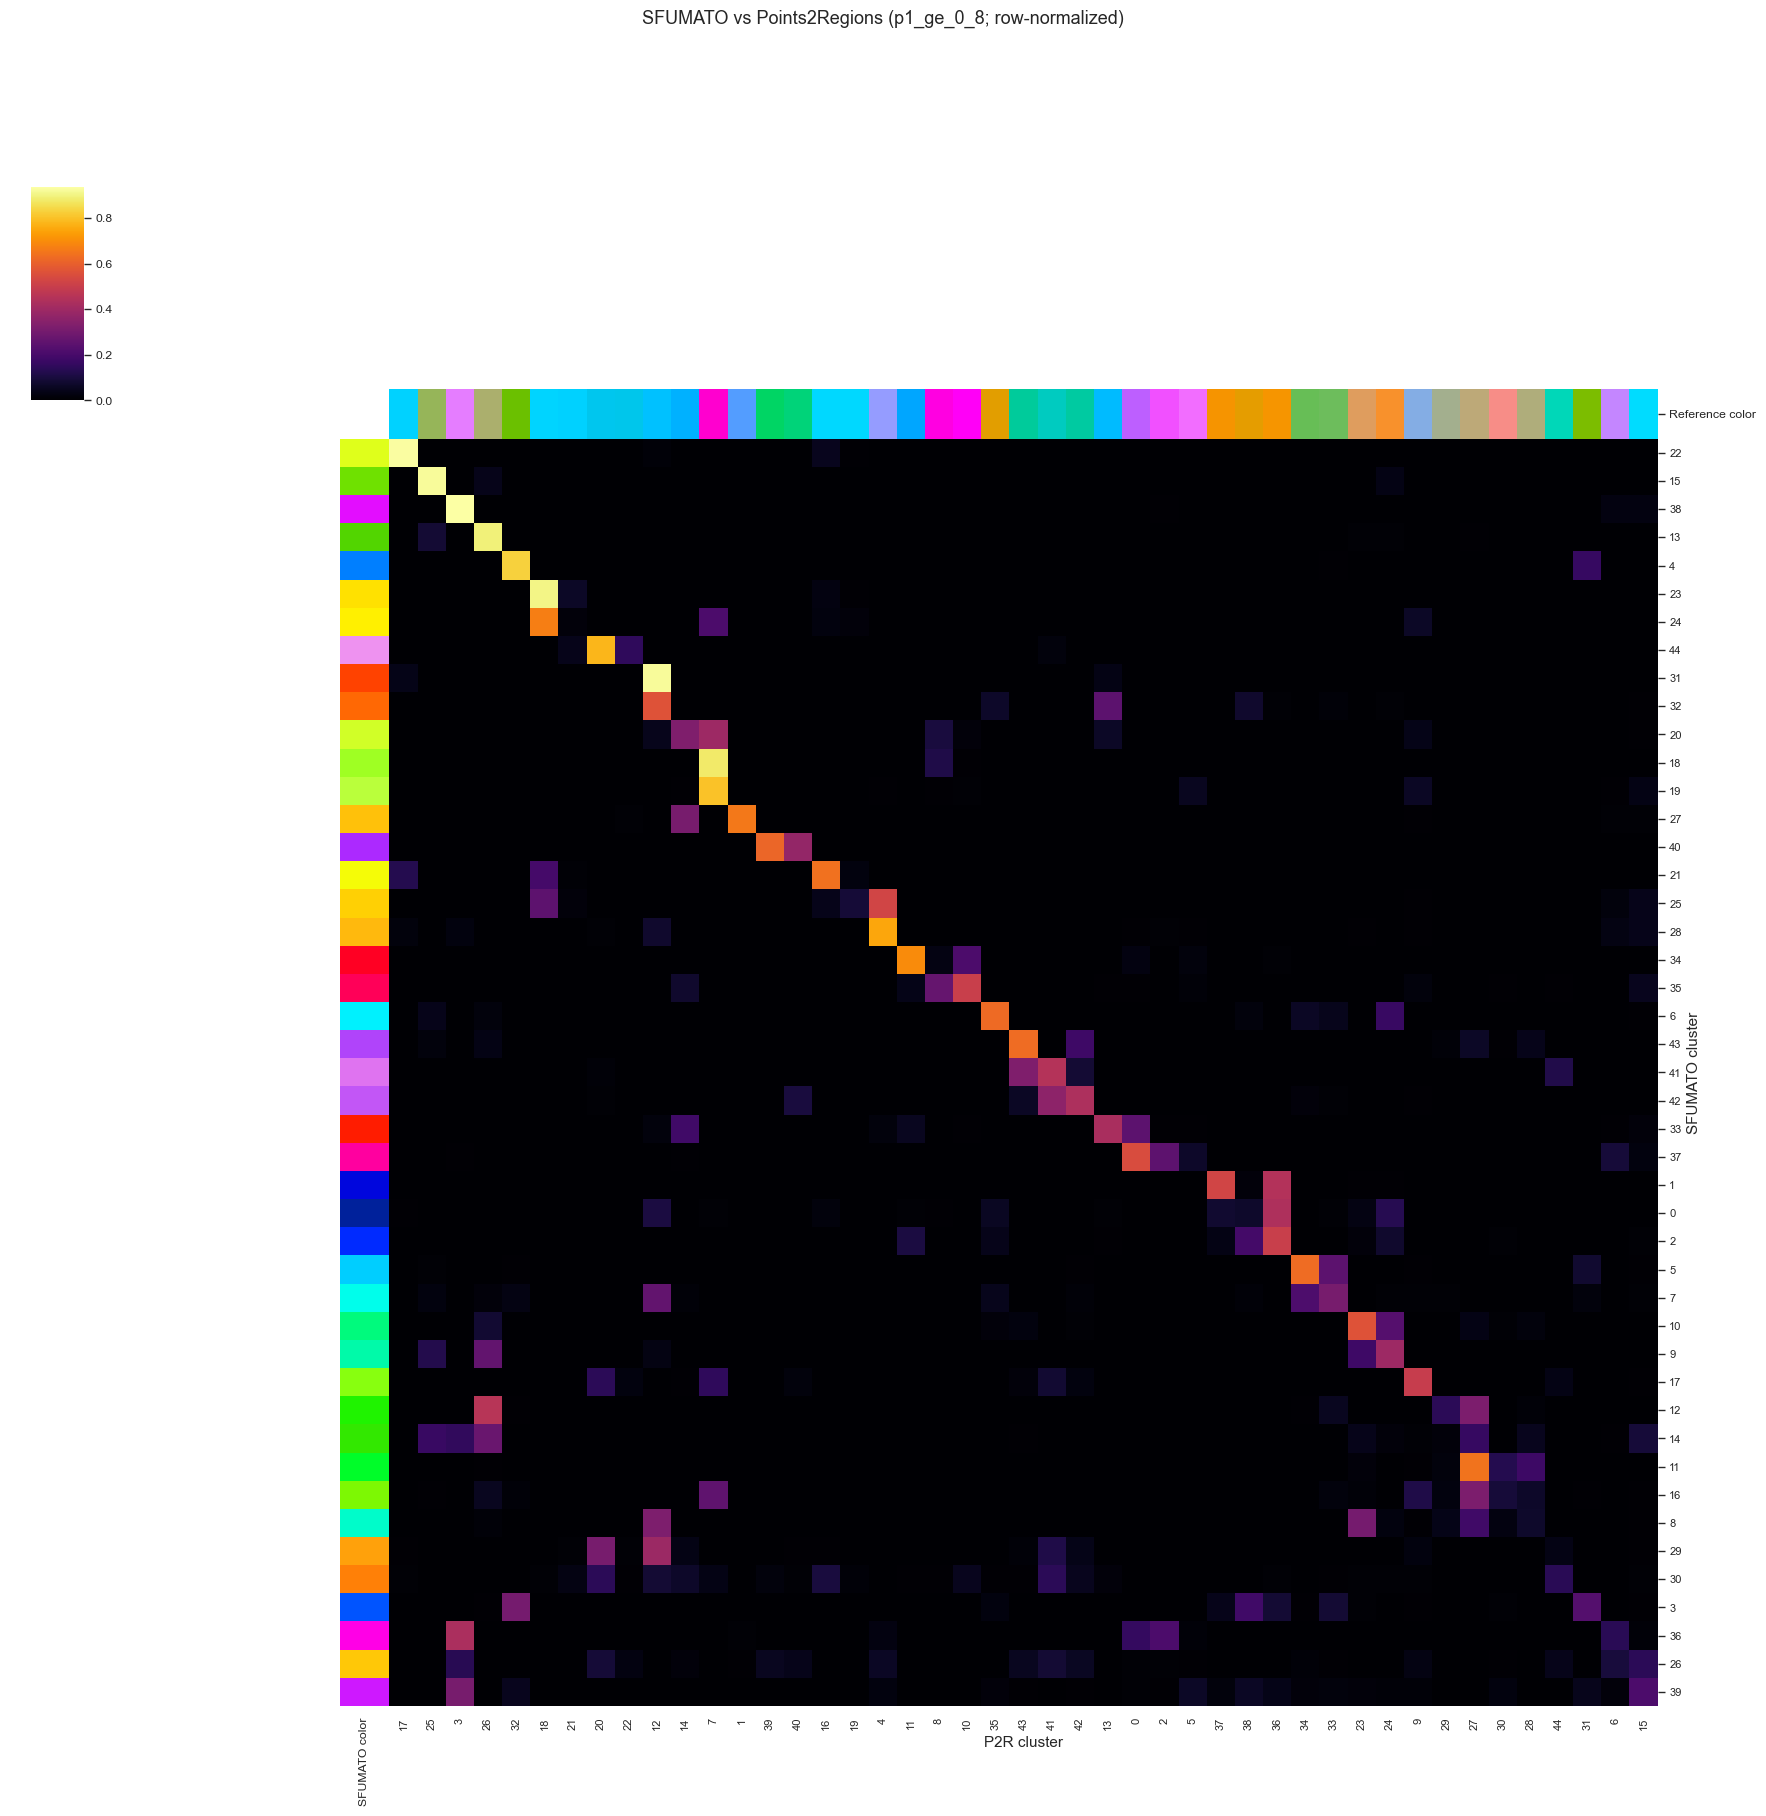

In [8]:
merged_high_conf = merged[merged["p1"] >= P1_THRESHOLD].copy()
print(f"High-confidence threshold: p1 >= {P1_THRESHOLD}")
print(f"High-confidence matched rows: {len(merged_high_conf):,} / {len(merged):,}")
g_high = run_p2r_comparison(merged_high_conf, label=f"p1_ge_{str(P1_THRESHOLD).replace('.', '_')}")
